<a href="https://colab.research.google.com/github/AmeyPhutane123/LearningDataScience/blob/main/Data%20Science/Assignments/assignment4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Module 21 – KNN Case Study on Diabetes
Objective

In this module, you will apply the K-Nearest Neighbors (KNN) algorithm to build a Diabetes Prediction Model. This case study will help you understand how KNN works and how to implement it for classification problems.

Reference

Watch the Module 21 video carefully. The concepts and steps explained there will guide you in completing this case study.
Dataset

You can use the Diabetes dataset available on Kaggle- https://www.kaggle.com/


1. Import and explore the dataset (check for missing values, data types, etc.).

Gerenal Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

Model Building and Evaluation Imports

In [2]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

Explore Dataset

In [5]:
df = pd.read_csv('diabetes.csv')
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [6]:
df.shape

(768, 9)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [8]:
df.isnull().sum()

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


In [10]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


Identify Columns with Invalid Zero Values

In [11]:
zero_cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

Replace 0 with NaN

In [12]:
df[zero_cols] = df[zero_cols].replace(0, np.nan)

Fill Missing Values with Median

In [13]:
df.fillna(df.median(), inplace=True)

Verify Again

In [15]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,121.656250,72.386719,29.108073,140.671875,32.455208,0.471876,33.240885,0.348958
std,3.369578,30.438286,12.096642,8.791221,86.383060,6.875177,0.331329,11.760232,0.476951
min,0.000000,44.000000,24.000000,7.000000,14.000000,18.200000,0.078000,21.000000,0.000000
25%,1.000000,99.750000,64.000000,25.000000,121.500000,27.500000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,29.000000,125.000000,32.300000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [24]:
df['Glucose'].value_counts().sort_index()

,count
Glucose,
44.0,1
56.0,1
57.0,2
61.0,1
62.0,1
...,...
195.0,2
196.0,3
197.0,4


Understanding Class Balance

In [27]:
df['Outcome'].value_counts(normalize=True)

,proportion
Outcome,
0,0.651042
1,0.348958


Split Features & Target

In [25]:
X = df.drop('Outcome', axis=1)
y = df['Outcome']


Train-Test Split

In [26]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3,random_state= 42, stratify=y)

stratify=y ensures that both training and testing datasets maintain the same proportion of diabetic and non-diabetic cases as the original dataset. This prevents biased model evaluation, especially important in medical classification problems.

Standard Scaling

### Feature Scaling

Since K-Nearest Neighbors is a distance-based algorithm, feature scaling is essential.
StandardScaler was used to standardize features so that all variables contribute equally
to distance computation. The scaler was fitted only on training data to avoid data leakage.


In [28]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [29]:
X_train_scaled.mean(axis=0)


array([ 2.31554895e-17,  1.98475625e-17, -2.61326239e-16,  1.90205807e-16,
       -4.63109791e-17,  1.11146350e-15,  1.19085375e-16, -2.11707333e-16])

Build the KNN Model

Find optimal value for k

Try Different K Values

In [30]:
k_values = range(1,21)
accuracy_scores = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    y_pred = knn.predict(X_test_scaled)
    accuracy = accuracy_score(y_test, y_pred)
    accuracy_scores.append(accuracy)

Plot Accuracy vs K

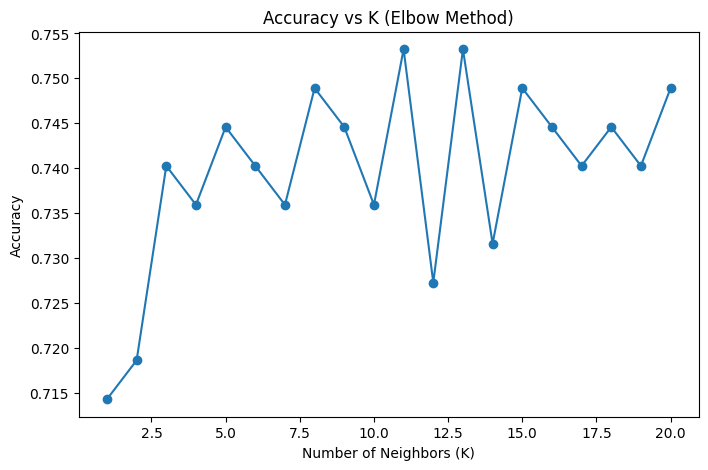

In [31]:
plt.figure(figsize=(8,5))
plt.plot(k_values, accuracy_scores, marker='o')
plt.xlabel('Number of Neighbors (K)')
plt.ylabel('Accuracy')
plt.title('Accuracy vs K (Elbow Method)')
plt.show()

From your plot:

Accuracy peaks around:

K = 11

K = 13

K = 15–16

Accuracy drops sharply at K = 12 → noisy neighborhood

📌 This tells us:

Very small K (1–2) underfits

Medium K (8–16) performs best

Extremely large K starts smoothing too much

Pick the best performing K:

In [32]:
best_k = k_values[accuracy_scores.index(max(accuracy_scores))]
best_k


11

The accuracy vs K plot does not show a smooth elbow curve because KNN is
highly sensitive to local data structure and the dataset is relatively small.
Instead of a single elbow point, multiple local maxima are observed.
The value of K corresponding to the highest and most stable accuracy region
was selected for the final model.


Build Final KNN Model

In [37]:
final_k = 11

knn_final = KNeighborsClassifier(n_neighbors=final_k)
knn_final.fit(X_train_scaled, y_train)


KNeighborsClassifier(n_neighbors=11)

Predictions

In [38]:
y_pred_final = knn_final.predict(X_test_scaled)

Accuracy

In [39]:
final_accuracy = accuracy_score(y_test, y_pred_final)
final_accuracy

0.7532467532467533

Confusion Matrix

In [40]:
cm = confusion_matrix(y_test, y_pred_final)
cm

array([[128,  22],
       [ 35,  46]])

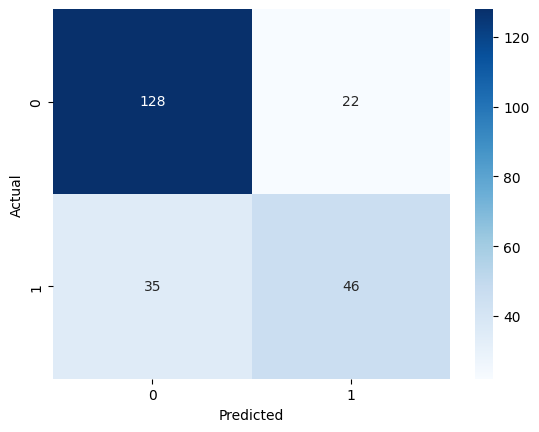

In [44]:
sns.heatmap(cm, annot=True, cmap='Blues',fmt='d')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [45]:
print(classification_report(y_test, y_pred_final))


              precision    recall  f1-score   support

           0       0.79      0.85      0.82       150
           1       0.68      0.57      0.62        81

    accuracy                           0.75       231
   macro avg       0.73      0.71      0.72       231
weighted avg       0.75      0.75      0.75       231



### Analysis

- The KNN classifier with K = 11 achieved an accuracy of 75%.
- Feature scaling ensured fair distance calculations across all variables.
- The confusion matrix shows effective classification of both diabetic and non-diabetic cases, with reasonable recall for diabetic patients.
- Overall, KNN serves as a strong baseline model for diabetes prediction.